# Классификация сетевого трафика: Normal vs DDoS

Этот ноутбук предназначен для датасета формата Bot-IoT / DDoS, где есть признаки:

`pkSeqID`, `stime`, `flgs`, `proto`, `saddr`, `daddr`, `pkts`, `bytes`, `state`, `dur`, `rate`, `attack`, `category`, `subcategory` и др.

**Цель:** классифицировать трафик на `Normal` и `DDoS`.

Важные решения:
- файл загружается по пути `DATA_PATH`;
- целевая переменная — `category`;
- перед обучением удаляются признаки с утечкой и идентификаторы;
- сначала выполняется `train_test_split`, затем under-sampling только на train;
- обучаются две модели;
- строятся матрицы ошибок;
- сохраняется `result.csv` с метриками и `test_predictions.csv` с предсказаниями.


## 0. Установка библиотек

Запустите ячейку, если библиотек нет.  
Команда `%pip` должна начинаться без пробела.


In [33]:
# Раскомментируйте при необходимости:
%pip install -q pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 1. Импорт библиотек и настройки

In [34]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Укажите путь к вашему CSV-файлу.
DATA_PATH = Path("DDoSdata.csv")

TARGET = "category"
CLASS_ORDER = ["Normal", "DDoS"]

# Для under-sampling: сколько DDoS оставить на один Normal.
# При 381 Normal в train и множителе 50 получится примерно 19 050 DDoS + 381 Normal.
MAJORITY_MULTIPLIER = 50

# Если True, SGDClassifier обучается на полном train с class_weight="balanced".
# Если False, SGDClassifier тоже обучается на under-sampling train.
TRAIN_SGD_ON_FULL_TRAIN = True

DATA_LOADED = False
CAN_TRAIN = False
STOP_REASON = ""


## 2. Загрузка данных

In [35]:
def reduce_mem_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Уменьшает потребление памяти числовыми столбцами."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Память: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df


if not DATA_PATH.exists():
    DATA_LOADED = False
    CAN_TRAIN = False
    STOP_REASON = f"Файл не найден: {DATA_PATH.resolve()}"
    print(STOP_REASON)
else:
    df = pd.read_csv(DATA_PATH, low_memory=False)
    df = reduce_mem_usage(df)
    DATA_LOADED = True

    print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
    display(df.head())
    display(df.info())


Память: 1460.45 MB -> 1177.42 MB
Размер датасета: 1927101 строк, 47 колонок


,Unnamed: 0,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1650261,1650261,1.528103e+09,e,1,tcp,1,192.168.100.150,54110,192.168.100.3,...,1.21662,40,38,1.56093,1.21662,328,308,1,DDoS,HTTP
1,1650262,1650262,1.528103e+09,e,1,tcp,1,192.168.100.150,54112,192.168.100.3,...,1.21662,40,38,1.56107,1.21662,328,308,1,DDoS,HTTP
2,1650263,1650263,1.528103e+09,e,1,tcp,1,192.168.100.150,54114,192.168.100.3,...,1.21662,40,38,1.24980,1.21662,328,308,1,DDoS,HTTP
3,1650264,1650264,1.528103e+09,e,1,tcp,1,192.168.100.150,54116,192.168.100.3,...,1.21662,40,38,1.24986,1.21662,328,308,1,DDoS,HTTP
4,1650265,1650265,1.528103e+09,e,1,tcp,1,192.168.100.150,54118,192.168.100.3,...,1.21662,40,38,1.24991,1.21662,328,308,1,DDoS,HTTP


<class 'pandas.DataFrame'>
RangeIndex: 1927101 entries, 0 to 1927100
Data columns (total 47 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Unnamed: 0                        int32  
 1   pkSeqID                           int32  
 2   stime                             float64
 3   flgs                              str    
 4   flgs_number                       int8   
 5   proto                             str    
 6   proto_number                      int8   
 7   saddr                             str    
 8   sport                             str    
 9   daddr                             str    
 10  dport                             str    
 11  pkts                              int32  
 12  bytes                             int32  
 13  state                             str    
 14  state_number                      int8   
 15  ltime                             float64
 16  seq                               int32  
 17  

None

## 3. Проверка целевой переменной

Эта ячейка специально защищена от ошибки `KeyError: 'Normal'`.  
Если `Normal` есть в полном файле, обучение продолжится. Если нет — ноутбук выведет понятную причину.


In [36]:
def normalize_category_values(s: pd.Series) -> pd.Series:
    """Приводит варианты написания классов к Normal и DDoS."""
    cleaned = s.astype(str).str.strip()
    lower = cleaned.str.lower()

    result = cleaned.copy()

    normal_aliases = {
        "normal", "benign", "legitimate", "regular", "no attack", "no_attack"
    }
    ddos_aliases = {
        "ddos", "d-dos", "distributed denial of service"
    }

    result[lower.isin(normal_aliases)] = "Normal"
    result[lower.isin(ddos_aliases)] = "DDoS"

    return result


if not DATA_LOADED:
    print("Пропуск проверки target.")
    print(STOP_REASON)
elif TARGET not in df.columns:
    CAN_TRAIN = False
    STOP_REASON = f"В датасете нет колонки '{TARGET}'. Доступные колонки: {df.columns.tolist()}"
    print(STOP_REASON)
else:
    print("Распределение category ДО нормализации:")
    display(df[TARGET].astype(str).str.strip().value_counts(dropna=False))

    df[TARGET] = normalize_category_values(df[TARGET])

    print("Распределение category ПОСЛЕ нормализации:")
    raw_counts = df[TARGET].value_counts(dropna=False)
    display(raw_counts)

    # Оставляем только нужные классы
    known_mask = df[TARGET].isin(CLASS_ORDER)
    unknown_count = int((~known_mask).sum())

    if unknown_count > 0:
        print(f"Удаляем строки с неизвестными значениями '{TARGET}': {unknown_count}")
        display(df.loc[~known_mask, TARGET].value_counts(dropna=False))

    df = df.loc[known_mask].copy()

    target_counts = df[TARGET].value_counts().reindex(CLASS_ORDER, fill_value=0)

    class_balance = pd.DataFrame({
        "count": target_counts,
        "share_%": (target_counts / max(target_counts.sum(), 1) * 100).round(5),
    })

    print("Итоговое распределение классов:")
    display(class_balance)

    missing_classes = [cls for cls in CLASS_ORDER if target_counts.loc[cls] == 0]

    if missing_classes:
        CAN_TRAIN = False
        STOP_REASON = (
            f"Нельзя обучить бинарную модель: отсутствуют классы {missing_classes}. "
            f"Распределение: {target_counts.to_dict()}"
        )
        print(STOP_REASON)
    elif target_counts.min() < 2:
        CAN_TRAIN = False
        STOP_REASON = (
            "Нельзя сделать stratified split: в одном из классов меньше 2 строк. "
            f"Распределение: {target_counts.to_dict()}"
        )
        print(STOP_REASON)
    else:
        CAN_TRAIN = True
        STOP_REASON = ""
        print("Оба класса есть. Можно продолжать обучение.")


Распределение category ДО нормализации:


category
DDoS      1926624
Normal        477
Name: count, dtype: int64

Распределение category ПОСЛЕ нормализации:


category
DDoS      1926624
Normal        477
Name: count, dtype: int64

Итоговое распределение классов:


,count,share_%
category,,
Normal,477,0.02475
DDoS,1926624,99.97525


Оба класса есть. Можно продолжать обучение.


## 4. Визуализация дисбаланса классов

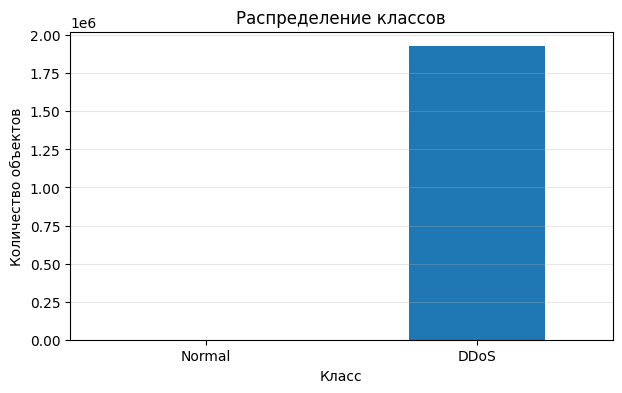

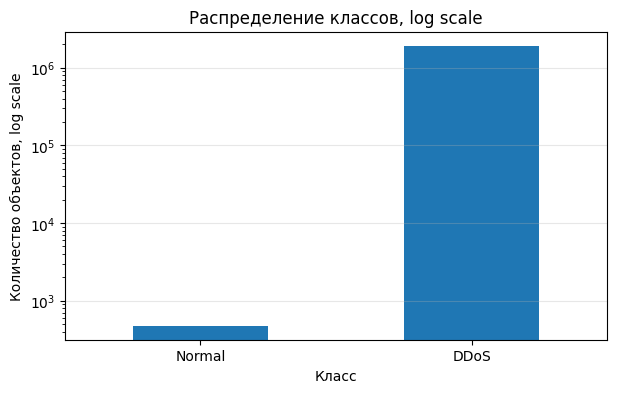

In [37]:
if not DATA_LOADED:
    print("Пропуск визуализации.")
    print(STOP_REASON)
else:
    plot_counts = df[TARGET].value_counts().reindex(CLASS_ORDER, fill_value=0)

    plt.figure(figsize=(7, 4))
    plot_counts.plot(kind="bar")
    plt.title("Распределение классов")
    plt.xlabel("Класс")
    plt.ylabel("Количество объектов")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plot_counts.replace(0, np.nan).plot(kind="bar", logy=True)
    plt.title("Распределение классов, log scale")
    plt.xlabel("Класс")
    plt.ylabel("Количество объектов, log scale")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


## 5. Удаление утечек и подготовка признаков

Удаляем:
- `category` — целевая переменная;
- `attack`, `subcategory` — прямые признаки разметки;
- `Unnamed: 0`, `pkSeqID`, `seq` — индексы/идентификаторы;
- `stime`, `ltime` — время, которое может привязать модель к порядку сбора данных;
- `saddr`, `daddr`, `sport`, `dport` — адреса и порты, которые часто приводят к запоминанию лабораторной топологии;
- `flgs_number`, `proto_number`, `state_number` — дубли числовых кодировок категорий.


In [38]:
if not CAN_TRAIN:
    print("Пропуск подготовки признаков.")
    print(STOP_REASON)
else:
    DROP_COLS = [
        # target / leakage
        "category", "attack", "subcategory",

        # identifiers / time
        "Unnamed: 0", "pkSeqID", "seq", "stime", "ltime",

        # network identifiers
        "saddr", "daddr", "sport", "dport",

        # duplicated encodings
        "flgs_number", "proto_number", "state_number",
    ]

    y = df[TARGET].copy()
    X = df.drop(columns=[col for col in DROP_COLS if col in df.columns], errors="ignore").copy()

    print("Размер X:", X.shape)
    print("Размер y:", y.shape)
    print("Оставшиеся признаки:")
    display(pd.Series(X.columns, name="feature"))


Размер X: (1927101, 32)
Размер y: (1927101,)
Оставшиеся признаки:


0                                 flgs
1                                proto
2                                 pkts
3                                bytes
4                                state
5                                  dur
6                                 mean
7                               stddev
8                                  sum
9                                  min
10                                 max
11                               spkts
12                               dpkts
13                              sbytes
14                              dbytes
15                                rate
16                               srate
17                               drate
18                           TnBPSrcIP
19                           TnBPDstIP
20                          TnP_PSrcIP
21                          TnP_PDstIP
22                        TnP_PerProto
23                       TnP_Per_Dport
24                  AR_P_Proto_P_SrcIP
25                  AR_P_

## 6. Определение категориальных и числовых признаков

In [39]:
if not CAN_TRAIN:
    print("Пропуск определения признаков.")
    print(STOP_REASON)
else:
    preferred_categorical = [c for c in ["flgs", "proto", "state"] if c in X.columns]

    object_cols = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
    MAX_CATEGORICAL_UNIQUE = 50

    extra_categorical = [
        c for c in object_cols
        if c not in preferred_categorical and X[c].nunique(dropna=True) <= MAX_CATEGORICAL_UNIQUE
    ]

    categorical_features = sorted(set(preferred_categorical + extra_categorical))

    # Удаляем оставшиеся object-признаки с высокой кардинальностью
    high_cardinality_cols = [c for c in object_cols if c not in categorical_features]
    if high_cardinality_cols:
        print("Удалены высококардинальные object-признаки:", high_cardinality_cols)
        X = X.drop(columns=high_cardinality_cols)

    numeric_features = [c for c in X.columns if c not in categorical_features]

    for col in numeric_features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X[numeric_features] = X[numeric_features].replace([np.inf, -np.inf], np.nan)

    print(f"Числовых признаков: {len(numeric_features)}")
    print(f"Категориальных признаков: {len(categorical_features)}")
    print("Категориальные признаки:", categorical_features)

    if len(numeric_features) + len(categorical_features) == 0:
        CAN_TRAIN = False
        STOP_REASON = "После удаления колонок не осталось признаков для обучения."
        print(STOP_REASON)


Числовых признаков: 29
Категориальных признаков: 3
Категориальные признаки: ['flgs', 'proto', 'state']


## 7. Train/test split до балансировки

Это важное отличие от многих простых примеров: сначала делим данные, затем балансируем только train.  
Так test остаётся честным и отражает реальный дисбаланс.


In [40]:
if not CAN_TRAIN:
    print("Пропуск train/test split.")
    print(STOP_REASON)
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    print("Train:", X_train.shape)
    print("Test:", X_test.shape)

    split_balance = pd.DataFrame({
        "train": y_train.value_counts().reindex(CLASS_ORDER, fill_value=0),
        "test": y_test.value_counts().reindex(CLASS_ORDER, fill_value=0),
    })
    display(split_balance)


Train: (1541680, 32)
Test: (385421, 32)


,train,test
category,,
Normal,382,95
DDoS,1541298,385326


## 8. Under-sampling обучающей выборки

При перекосе примерно 2 млн DDoS и 500 Normal нельзя размножать меньший класс до миллионов строк.  
Экономнее оставить все `Normal` и ограниченное число `DDoS`.


До under-sampling:


category
Normal        382
DDoS      1541298
Name: count, dtype: int64

После under-sampling:


category
Normal      382
DDoS      19100
Name: count, dtype: int64

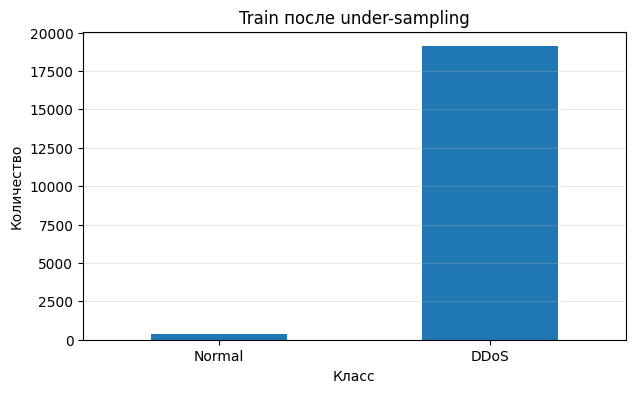

In [41]:
def make_under_sample(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    majority_label: str = "DDoS",
    minority_label: str = "Normal",
    majority_multiplier: int = 50,
    random_state: int = 42,
):
    """Оставляет все minority и ограниченное количество majority."""
    counts = y_train.value_counts().reindex([minority_label, majority_label], fill_value=0)

    n_minority = int(counts.loc[minority_label])
    n_majority = int(counts.loc[majority_label])

    if n_minority == 0 or n_majority == 0:
        raise ValueError(f"В train должны быть оба класса. Сейчас: {counts.to_dict()}")

    n_majority_keep = min(n_majority, n_minority * majority_multiplier)

    minority_idx = y_train[y_train == minority_label].index
    majority_idx = y_train[y_train == majority_label].sample(
        n=n_majority_keep,
        random_state=random_state,
        replace=False,
    ).index

    sampled_idx = pd.Index(list(minority_idx) + list(majority_idx))
    sampled_idx = pd.Series(sampled_idx).sample(frac=1.0, random_state=random_state).to_numpy()

    return X_train.loc[sampled_idx].copy(), y_train.loc[sampled_idx].copy()


if not CAN_TRAIN:
    print("Пропуск under-sampling.")
    print(STOP_REASON)
else:
    print("До under-sampling:")
    display(y_train.value_counts().reindex(CLASS_ORDER, fill_value=0))

    X_train_rus, y_train_rus = make_under_sample(
        X_train,
        y_train,
        majority_label="DDoS",
        minority_label="Normal",
        majority_multiplier=MAJORITY_MULTIPLIER,
        random_state=RANDOM_STATE,
    )

    print("После under-sampling:")
    display(y_train_rus.value_counts().reindex(CLASS_ORDER, fill_value=0))

    plt.figure(figsize=(7, 4))
    y_train_rus.value_counts().reindex(CLASS_ORDER, fill_value=0).plot(kind="bar")
    plt.title("Train после under-sampling")
    plt.xlabel("Класс")
    plt.ylabel("Количество")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


## 9. Пайплайны предобработки

In [42]:
def make_onehot_encoder():
    """OneHotEncoder с совместимостью разных версий sklearn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)


def make_ordinal_encoder():
    """OrdinalEncoder с совместимостью разных версий sklearn."""
    try:
        return OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
        )
    except TypeError:
        return OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )


if not CAN_TRAIN:
    print("Пропуск создания препроцессоров.")
    print(STOP_REASON)
else:
    linear_transformers = []
    tree_transformers = []

    if numeric_features:
        linear_transformers.append((
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ))

        tree_transformers.append((
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ))

    if categorical_features:
        linear_transformers.append((
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_onehot_encoder()),
            ]),
            categorical_features,
        ))

        tree_transformers.append((
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", make_ordinal_encoder()),
            ]),
            categorical_features,
        ))

    linear_preprocessor = ColumnTransformer(
        transformers=linear_transformers,
        remainder="drop",
        sparse_threshold=0.3,
    )

    tree_preprocessor = ColumnTransformer(
        transformers=tree_transformers,
        remainder="drop",
    )

    print("Пайплайны предобработки готовы.")


Пайплайны предобработки готовы.


## 10. Обучение моделей

Обучаются три модели:

1. `SGDClassifier` — быстрая линейная модель, масштабируемая на большие данные;
2. `RandomForestClassifier` — нелинейная модель на under-sampling выборке;
3. `HistGradientBoostingClassifier` — градиентный бустинг из sklearn на under-sampling выборке.

Минимум две модели выполнен, третья добавлена для сравнения.


In [43]:
if not CAN_TRAIN:
    print("Пропуск обучения.")
    print(STOP_REASON)
else:
    models = {}

    # 1. Масштабируемая линейная модель
    sgd_model = Pipeline(steps=[
        ("preprocess", linear_preprocessor),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-4,
            class_weight="balanced",
            max_iter=1000,
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    if TRAIN_SGD_ON_FULL_TRAIN:
        print("Обучаем SGDClassifier на полном train...")
        sgd_model.fit(X_train, y_train)
    else:
        print("Обучаем SGDClassifier на under-sampling train...")
        sgd_model.fit(X_train_rus, y_train_rus)

    models["SGDClassifier"] = sgd_model

    # 2. Random Forest на under-sampling train
    rf_model = Pipeline(steps=[
        ("preprocess", tree_preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=150,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    print("Обучаем RandomForestClassifier на under-sampling train...")
    rf_model.fit(X_train_rus, y_train_rus)
    models["RandomForest_RUS"] = rf_model

    # 3. HistGradientBoosting на under-sampling train
    hgb_model = Pipeline(steps=[
        ("preprocess", tree_preprocessor),
        ("clf", HistGradientBoostingClassifier(
            max_iter=250,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            early_stopping=False,
            random_state=RANDOM_STATE,
        )),
    ])

    print("Обучаем HistGradientBoostingClassifier на under-sampling train...")
    hgb_weights = compute_sample_weight(class_weight="balanced", y=y_train_rus)
    hgb_model.fit(X_train_rus, y_train_rus, clf__sample_weight=hgb_weights)
    models["HistGradientBoosting_RUS"] = hgb_model

    print("Обученные модели:", list(models.keys()))


Обучаем SGDClassifier на полном train...
Обучаем RandomForestClassifier на under-sampling train...
Обучаем HistGradientBoostingClassifier на under-sampling train...
Обученные модели: ['SGDClassifier', 'RandomForest_RUS', 'HistGradientBoosting_RUS']


## 11. Оценка моделей и матрицы ошибок

SGDClassifier
              precision    recall  f1-score   support

      Normal     0.8879    1.0000    0.9406        95
        DDoS     1.0000    1.0000    1.0000    385326

    accuracy                         1.0000    385421
   macro avg     0.9439    1.0000    0.9703    385421
weighted avg     1.0000    1.0000    1.0000    385421



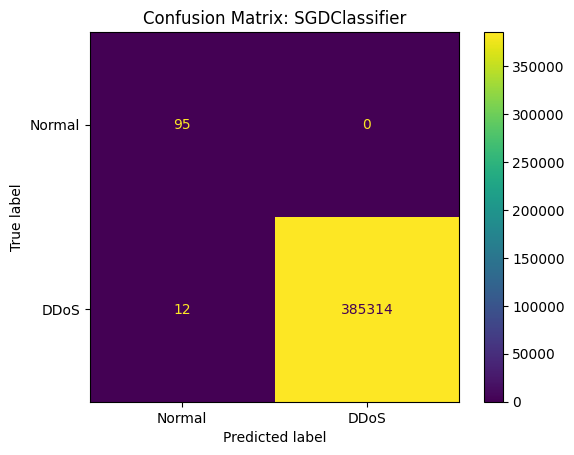

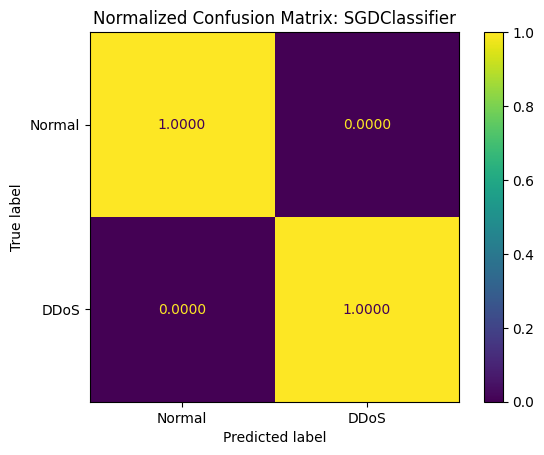

RandomForest_RUS
              precision    recall  f1-score   support

      Normal     0.8879    1.0000    0.9406        95
        DDoS     1.0000    1.0000    1.0000    385326

    accuracy                         1.0000    385421
   macro avg     0.9439    1.0000    0.9703    385421
weighted avg     1.0000    1.0000    1.0000    385421



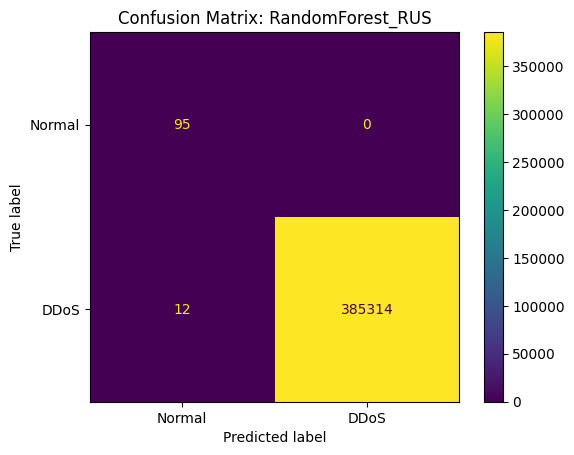

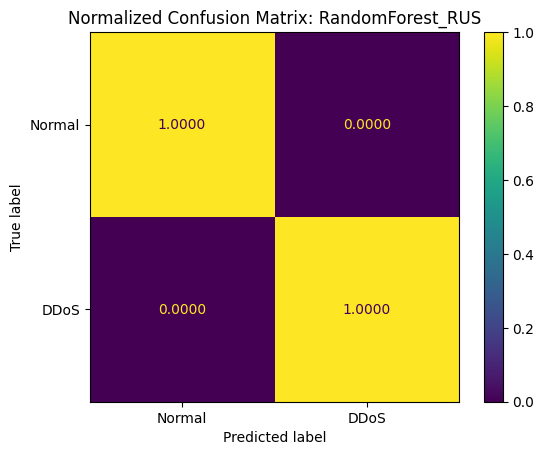

HistGradientBoosting_RUS
              precision    recall  f1-score   support

      Normal     0.8636    1.0000    0.9268        95
        DDoS     1.0000    1.0000    1.0000    385326

    accuracy                         1.0000    385421
   macro avg     0.9318    1.0000    0.9634    385421
weighted avg     1.0000    1.0000    1.0000    385421



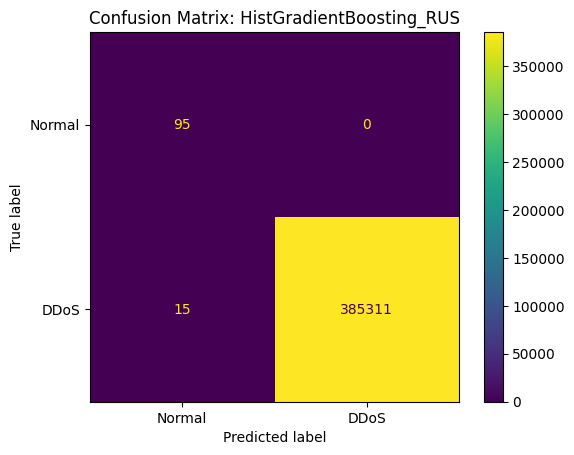

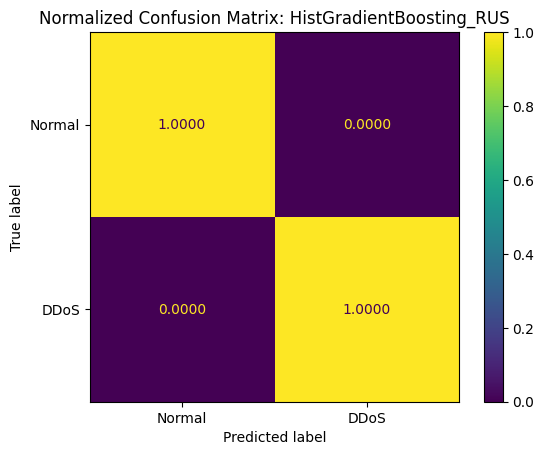

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,normal_precision,normal_recall,normal_f1,ddos_precision,ddos_recall,ddos_f1,average_precision_Normal
1,RandomForest_RUS,0.999969,0.999984,0.943925,0.999984,0.970289,0.887850,1.0,0.940594,1.0,0.999969,0.999984,0.998052
0,SGDClassifier,0.999969,0.999984,0.943925,0.999984,0.970289,0.887850,1.0,0.940594,1.0,0.999969,0.999984,0.931373
2,HistGradientBoosting_RUS,0.999961,0.999981,0.931818,0.999981,0.963405,0.863636,1.0,0.926829,1.0,0.999961,0.999981,0.973927


In [44]:
def get_score_for_class(model, X_eval: pd.DataFrame, class_label: str) -> np.ndarray:
    """Возвращает probability или decision score для указанного класса."""
    estimator = model.named_steps["clf"]
    classes = list(estimator.classes_)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)
        return proba[:, classes.index(class_label)]

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_eval)
        if scores.ndim == 1:
            return scores if class_label == classes[1] else -scores
        return scores[:, classes.index(class_label)]

    raise AttributeError("Модель не поддерживает predict_proba или decision_function.")


def evaluate_model(model_name: str, model, X_eval: pd.DataFrame, y_eval: pd.Series) -> dict:
    """Считает метрики и строит confusion matrix."""
    y_pred = model.predict(X_eval)

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(
        y_eval,
        y_pred,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        digits=4,
        zero_division=0,
    ))

    report = classification_report(
        y_eval,
        y_pred,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )

    try:
        normal_score = get_score_for_class(model, X_eval, "Normal")
        ap_normal = average_precision_score((y_eval == "Normal").astype(int), normal_score)
    except Exception:
        ap_normal = np.nan

    cm = confusion_matrix(y_eval, y_pred, labels=CLASS_ORDER)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.grid(False)
    plt.show()

    cm_norm = confusion_matrix(y_eval, y_pred, labels=CLASS_ORDER, normalize="true")
    disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_ORDER)
    disp_norm.plot(values_format=".4f")
    plt.title(f"Normalized Confusion Matrix: {model_name}")
    plt.grid(False)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
        "macro_precision": precision_score(y_eval, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0),
        "macro_recall": recall_score(y_eval, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0),
        "macro_f1": f1_score(y_eval, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0),
        "normal_precision": report["Normal"]["precision"],
        "normal_recall": report["Normal"]["recall"],
        "normal_f1": report["Normal"]["f1-score"],
        "ddos_precision": report["DDoS"]["precision"],
        "ddos_recall": report["DDoS"]["recall"],
        "ddos_f1": report["DDoS"]["f1-score"],
        "average_precision_Normal": ap_normal,
    }


if not CAN_TRAIN:
    print("Пропуск оценки.")
    print(STOP_REASON)
else:
    results = []

    for name, model in models.items():
        results.append(evaluate_model(name, model, X_test, y_test))

    results_df = pd.DataFrame(results).sort_values(
        by=["macro_f1", "balanced_accuracy", "average_precision_Normal"],
        ascending=False,
    )

    display(results_df)


## 12. Сохранение `result.csv`

Сохраняем:
- `result.csv` — таблица метрик по моделям;
- `test_predictions.csv` — истинные и предсказанные классы на тестовой выборке;
- лучшую модель в `.joblib`.


In [45]:
if not CAN_TRAIN:
    print("Сохранение пропущено.")
    print(STOP_REASON)
else:
    # 1. Метрики моделей
    results_df.to_csv("result.csv", index=False, encoding="utf-8-sig")
    print("Метрики сохранены в result.csv")

    # 2. Предсказания на тестовой выборке
    predictions_df = pd.DataFrame({
        "y_true": y_test.reset_index(drop=True),
    })

    for name, model in models.items():
        predictions_df[f"pred_{name}"] = model.predict(X_test)

        try:
            predictions_df[f"score_Normal_{name}"] = get_score_for_class(model, X_test, "Normal")
        except Exception:
            pass

    predictions_df.to_csv("test_predictions.csv", index=False, encoding="utf-8-sig")
    print("Предсказания сохранены в test_predictions.csv")

    # 3. Лучшая модель
    best_model_name = results_df.iloc[0]["model"]
    best_model = models[best_model_name]

    model_path = Path(f"best_model_{best_model_name}.joblib")
    joblib.dump(best_model, model_path)

    print(f"Лучшая модель: {best_model_name}")
    print(f"Модель сохранена: {model_path.resolve()}")


Метрики сохранены в result.csv
Предсказания сохранены в test_predictions.csv
Лучшая модель: RandomForest_RUS
Модель сохранена: C:\Users\lab_a\Documents\best_model_RandomForest_RUS.joblib


## 13. Краткий вывод

Выбор лучшей модели выполняется по `macro_f1`, затем по `balanced_accuracy`.


In [46]:
if not CAN_TRAIN:
    print("Вывод недоступен.")
    print(STOP_REASON)
else:
    best = results_df.iloc[0]

    print(
        f"Лучшая модель: {best['model']}\n"
        f"macro_f1 = {best['macro_f1']:.4f}\n"
        f"balanced_accuracy = {best['balanced_accuracy']:.4f}\n"
        f"normal_recall = {best['normal_recall']:.4f}\n"
        f"ddos_recall = {best['ddos_recall']:.4f}"
    )

    print(
        "\nПочему это важно: при экстремальном дисбалансе обычная accuracy может быть обманчивой. "
        "Поэтому для выбора модели важнее смотреть macro-F1, balanced accuracy и recall редкого класса Normal."
    )


Лучшая модель: RandomForest_RUS
macro_f1 = 0.9703
balanced_accuracy = 1.0000
normal_recall = 1.0000
ddos_recall = 1.0000

Почему это важно: при экстремальном дисбалансе обычная accuracy может быть обманчивой. Поэтому для выбора модели важнее смотреть macro-F1, balanced accuracy и recall редкого класса Normal.
